# Personal Information
Name: **Matt Boerio**

StudentID: **16153588**

Email: [**matt.boerio@student.uva.nl**](matt.boerio@student.uva.nl)

Submitted on: **19.03.2026**

Github link: https://github.com/boeriomatt/SHROOM-SemEval-2024-Task-6-Model-Size-in-Detection-of-LLM-Hallucinations

## Data Context
This notebook explores the SHROOM model-agnostic datasets found here: https://helsinki-nlp.github.io/shroom/2024. Framed as a binary classification problem over LLM-generated outputs, SHROOM evaluates whether a response contains hallucinated content across several NLG tasks. The SHROOM task frames hallucination detection as a binary classification problem over model outputs. Each example contains a source (`src`), a target/reference (`tgt`), a model hypothesis (`hyp`), a task label, individual annotator labels, a majority label, and the empirical probability of hallucination.

This notebook focuses only on the model-agnostic data: the trial set (not intended to be used, but may provide additional data for model fine-tuning), the development/validation set (intended to be used for model fine-tuning), and the labeled test set (final evaluation set).

# Data Description
See EDA analysis below. The main goal of this notebook is to understand the class balance, annotation uncertainty, task composition, text characteristics, and potential data quality issues before building hallucination detection models.

In [2]:
# imports
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

## Data Loading

In [3]:
# load in data
base_path = Path('..') / 'data'

paths = {
    'trial': base_path / 'SHROOM_trial-v1.1' / 'trial-v1.json',
    'dev': base_path / 'SHROOM_dev-v2' / 'val.model-agnostic.json',
    'test': base_path / 'SHROOM_test-labeled' / 'test.model-agnostic.json',
}

dfs = {}
for split, path in paths.items():
    df = pd.read_json(path)
    df['split'] = split
    dfs[split] = df

# all datasets
combined_df = pd.concat(dfs.values(), ignore_index=True)

for split, df in dfs.items():
    print(f'{split}: {df.shape[0]} rows, {df.shape[1]} columns')

print(f'combined data: {combined_df.shape[0]} rows, {combined_df.shape[1]} colums')
display(combined_df.head())

# trial data
trial_df = dfs["trial"]
print(f'trial data: {trial_df.shape[0]} rows, {trial_df.shape[1]} colums')
display(trial_df.head())

# dev data
dev_df = dfs["dev"]
print(f'dev data: {dev_df.shape[0]} rows, {dev_df.shape[1]} colums')
display(dev_df.head())

# test data
test_df = dfs["test"]
print(f'test data: {test_df.shape[0]} rows, {test_df.shape[1]} colums')
display(test_df.head())

# export to excel
combined_df.to_excel("shroom_dataset.xlsx", index=False)

'''
Notes:
- trial and dev sets have same cols; only trial has some instances of model specifically given
- test set has additional id col and missing model and ref cols (shouldn't use these to model with anyways, so not an issue)
'''

trial: 80 rows, 10 columns
dev: 499 rows, 10 columns
test: 1500 rows, 9 columns
combined data: 2079 rows, 11 colums


,hyp,ref,src,tgt,model,task,labels,label,p(Hallucination),split,id
0,"A district of Kowloon, China.",tgt,The City <define> Chiuchow </define> is Kowloo...,The Chaoshan region where the Teochew dialect ...,,DM,"[Hallucination, Hallucination, Hallucination]",Hallucination,1.000000,trial,NaN
1,(Wicca) A witchdoctor.,tgt,"“ I went to see the witchdoctor , the <define>...",(South Africa) A traditional tribal diviner or...,,DM,"[Hallucination, Hallucination, Not Hallucination]",Hallucination,0.666667,trial,NaN
2,(nautical) A halyard.,tgt,"Haul away , keeping strain on both parts of th...",(nautical) A staff that carries a flag or penn...,,DM,"[Hallucination, Not Hallucination, Not Halluci...",Not Hallucination,0.333333,trial,NaN
3,The quality of being rational.,tgt,And what difference is there between the credi...,(archaic) The quality or state of being rational.,,DM,"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.000000,trial,NaN
4,(uncountable) The study of trees.,tgt,It is now generally supposed that the forbidde...,The worship of trees.,,DM,"[Hallucination, Hallucination, Hallucination]",Hallucination,1.000000,trial,NaN


trial data: 80 rows, 10 colums


,hyp,ref,src,tgt,model,task,labels,label,p(Hallucination),split
0,"A district of Kowloon, China.",tgt,The City <define> Chiuchow </define> is Kowloo...,The Chaoshan region where the Teochew dialect ...,,DM,"[Hallucination, Hallucination, Hallucination]",Hallucination,1.000000,trial
1,(Wicca) A witchdoctor.,tgt,"“ I went to see the witchdoctor , the <define>...",(South Africa) A traditional tribal diviner or...,,DM,"[Hallucination, Hallucination, Not Hallucination]",Hallucination,0.666667,trial
2,(nautical) A halyard.,tgt,"Haul away , keeping strain on both parts of th...",(nautical) A staff that carries a flag or penn...,,DM,"[Hallucination, Not Hallucination, Not Halluci...",Not Hallucination,0.333333,trial
3,The quality of being rational.,tgt,And what difference is there between the credi...,(archaic) The quality or state of being rational.,,DM,"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.000000,trial
4,(uncountable) The study of trees.,tgt,It is now generally supposed that the forbidde...,The worship of trees.,,DM,"[Hallucination, Hallucination, Hallucination]",Hallucination,1.000000,trial


dev data: 499 rows, 10 colums


,hyp,ref,src,tgt,model,task,labels,label,p(Hallucination),split
0,Resembling or characteristic of a weasel.,tgt,The writer had just entered into his eighteent...,Resembling a weasel (in appearance).,,DM,"[Hallucination, Not Hallucination, Not Halluci...",Not Hallucination,0.2,dev
1,Alternative form of sheath knife,tgt,Sailors ' and fishermen 's <define> sheath - k...,.,,DM,"[Hallucination, Hallucination, Hallucination, ...",Hallucination,0.8,dev
2,(obsolete) A short period of time.,tgt,"As to age , Bead could not form any clear impr...","(poetic) An instant, a short moment.",,DM,"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,dev
3,(slang) An incel.,tgt,Because redpillers are usually normies or <def...,"(incel, _, slang) A man of a slightly lower ra...",,DM,"[Not Hallucination, Not Hallucination, Halluci...",Not Hallucination,0.2,dev
4,"An island in Lienchiang County, Taiwan.",tgt,On the second day of massive live - fire drill...,"An island in Dongyin, Lienchiang, Taiwan, in t...",,DM,"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,dev


test data: 1500 rows, 9 colums


,id,src,tgt,hyp,task,labels,label,p(Hallucination),split
0,1,"Ты удивишься, если я скажу, что на самом деле ...",Would you be surprised if I told you my name i...,You're gonna be surprised if I say my real nam...,MT,"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.0,test
1,2,Еды будет полно.,There will be plenty of food.,The food will be full.,MT,"[Hallucination, Not Hallucination, Hallucinati...",Hallucination,0.8,test
2,3,"Думаете, Том будет меня ждать?",Do you think that Tom will wait for me?,You think Tom's gonna wait for me?,MT,"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.2,test
3,6,Два брата довольно разные.,The two brothers are pretty different.,There's a lot of friends.,MT,"[Hallucination, Hallucination, Hallucination, ...",Hallucination,1.0,test
4,7,<define> Infradiaphragmatic </define> intra- a...,(medicine) Below the diaphragm.,(anatomy) Relating to the diaphragm.,DM,"[Hallucination, Hallucination, Hallucination, ...",Hallucination,0.8,test


"\nNotes:\n- trial and dev sets have same cols; only trial has some instances of model specifically given\n- test set has additional id col and missing model and ref cols (shouldn't use these to model with anyways, so not an issue)\n"

## Analysis 1: Dataset Audit

This section looks at column availability, missing values, and basic schema differences between the three splits.

In [4]:
# audit for data quality
audit_rows = []

for split, df in dfs.items():
    audit_rows.append({
        'split': split,
        'rows': len(df),
        'columns': len(df.columns),
        'has_ref': 'ref' in df.columns,
        'has_model': 'model' in df.columns,
        'missing_src': int(df['src'].isna().sum()),
        'missing_tgt': int(df['tgt'].isna().sum()),
        'missing_hyp': int(df['hyp'].isna().sum()),
        'missing_task': int(df['task'].isna().sum()),
        'missing_label': int(df['label'].isna().sum()),
        'missing_p_hall': int(df['p(Hallucination)'].isna().sum()),
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

for split, df in dfs.items():
    print(split, sorted(df.columns.tolist()))

'''
Notes:
- no noticable data issues
'''

,split,rows,columns,has_ref,has_model,missing_src,missing_tgt,missing_hyp,missing_task,missing_label,missing_p_hall
0,trial,80,10,True,True,0,0,0,0,0,0
1,dev,499,10,True,True,0,0,0,0,0,0
2,test,1500,9,False,False,0,0,0,0,0,0


trial ['hyp', 'label', 'labels', 'model', 'p(Hallucination)', 'ref', 'split', 'src', 'task', 'tgt']
dev ['hyp', 'label', 'labels', 'model', 'p(Hallucination)', 'ref', 'split', 'src', 'task', 'tgt']
test ['hyp', 'id', 'label', 'labels', 'p(Hallucination)', 'split', 'src', 'task', 'tgt']


'\nNotes:\n- no noticable data issues\n'

## Analysis 2: Label Distribution

This section explores the class balance overall and within each task.

,split,task,label,count,share_within_split_task
0,dev,DM,Hallucination,92,0.492
1,dev,DM,Not Hallucination,95,0.508
2,dev,MT,Hallucination,81,0.433
3,dev,MT,Not Hallucination,106,0.567
4,dev,PG,Hallucination,45,0.360
5,dev,PG,Not Hallucination,80,0.640
6,test,DM,Hallucination,288,0.512
7,test,DM,Not Hallucination,275,0.488
8,test,MT,Hallucination,226,0.402
9,test,MT,Not Hallucination,336,0.598


label,Hallucination,Not Hallucination,Percentage_Hallucination,percentage_not-hallucination
split,,,,
dev,218,281,0.437,0.563
test,611,889,0.407,0.593
trial,42,38,0.525,0.475


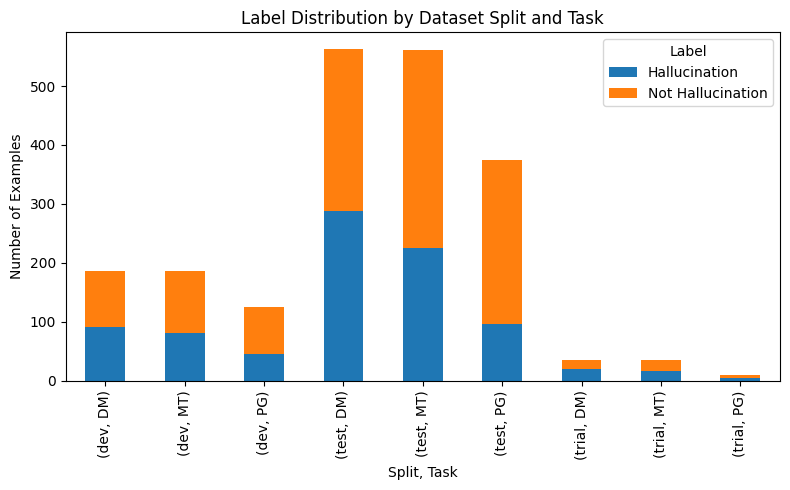

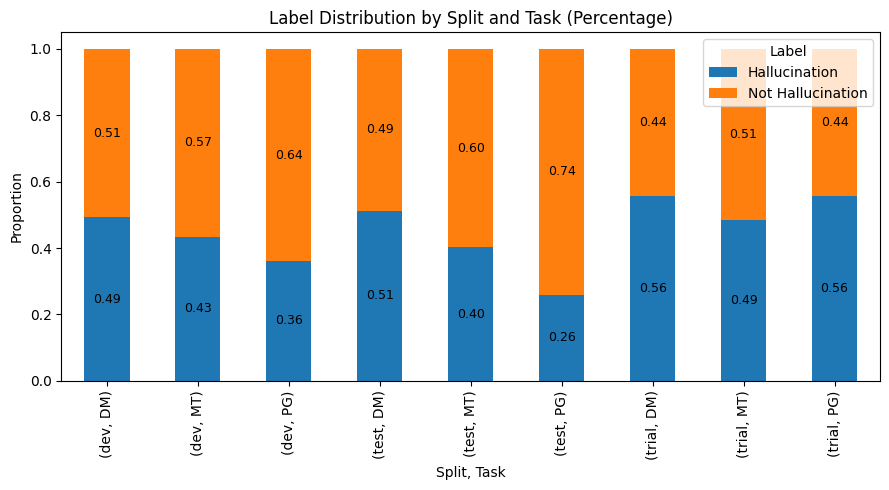

'\nNotes:\n- DM (Definition Modeling) is nearly balanced across all splits (~49-56% hallucination)\n- MT (Machine Translation) shows a moderate skew toward Not Hallucination (~56-60%)\n- PG is the most imbalanced task, especially in the test set (25.9% hallucination, 74.1% not hallucination)\n- overall, hallucination frequency varies substantially by task, with PG having the strongest skew toward non-hallucinated outputs\n- trial split is roughly balanced (~52% hallucination)\n- dev and test splits are skewed toward Not Hallucination; test set has the strongest imbalance, with ~59% non-hallucinated examples\n'

In [5]:
# analyze label (hallucination vs. not hallucination) distribution
label_summary = (
    combined_df
    .groupby(['split', 'task', 'label'])
    .size()
    .rename('count')
    .reset_index()
)

label_summary['share_within_split_task'] = (
    label_summary['count']
    / label_summary.groupby(['split', 'task'])['count'].transform('sum')
).round(3)

display(label_summary)

overall_label_balance = (
    combined_df
    .groupby(['split', 'label'])
    .size()
    .unstack(fill_value=0)
)

overall_label_balance['Percentage_Hallucination'] = (
    overall_label_balance['Hallucination']
    / (overall_label_balance['Hallucination'] + overall_label_balance['Not Hallucination'])
).round(3)

overall_label_balance['percentage_not-hallucination'] = (
    1 - overall_label_balance['Percentage_Hallucination']
).round(3)

display(overall_label_balance)

# visual - counts
import matplotlib.pyplot as plt

plot_df = (
    combined_df
    .groupby(['split', 'task', 'label'])
    .size()
    .unstack()
)

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Label Distribution by Dataset Split and Task")
plt.ylabel("Number of Examples")
plt.xlabel("Split, Task")
plt.legend(title="Label")
plt.tight_layout()

plt.show()

# visual - percentages
import matplotlib.pyplot as plt

plot_df = (
    combined_df
    .groupby(['split','task','label'])
    .size()
)

plot_df = plot_df / plot_df.groupby(level=[0,1]).transform('sum')
plot_df = plot_df.unstack()

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5)
)

for container in ax.containers:
    labels = [f"{v:.2f}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

plt.title("Label Distribution by Split and Task (Percentage)")
plt.ylabel("Proportion")
plt.xlabel("Split, Task")
plt.legend(title="Label")

plt.tight_layout()
plt.show()

'''
Notes:
- DM (Definition Modeling) is nearly balanced across all splits (~49-56% hallucination)
- MT (Machine Translation) shows a moderate skew toward Not Hallucination (~56-60%)
- PG is the most imbalanced task, especially in the test set (25.9% hallucination, 74.1% not hallucination)
- overall, hallucination frequency varies substantially by task, with PG having the strongest skew toward non-hallucinated outputs
- trial split is roughly balanced (~52% hallucination)
- dev and test splits are skewed toward Not Hallucination; test set has the strongest imbalance, with ~59% non-hallucinated examples
'''

## Analysis 3: Annotation Uncertainty

The `p(Hallucination)` column gives the proportion of annotators who marked a sample as hallucination. This section explores how much ambiguity exists in each split and task.

,split,task,p(Hallucination),count
0,dev,DM,0.000000,26
1,dev,DM,0.200000,35
2,dev,DM,0.400000,34
3,dev,DM,0.600000,29
4,dev,DM,0.800000,34
5,dev,DM,1.000000,29
6,dev,MT,0.000000,53
7,dev,MT,0.200000,32
8,dev,MT,0.400000,21
9,dev,MT,0.600000,22


agreement_strength  full_agreement  partial_agreement
split task                                           
dev   DM                        55                132
      MT                        92                 95
      PG                        36                 89
test  DM                       164                399
      MT                       246                316
      PG                       153                222
trial DM                        29                  7
      MT                        27                  8
      PG                         5                  4

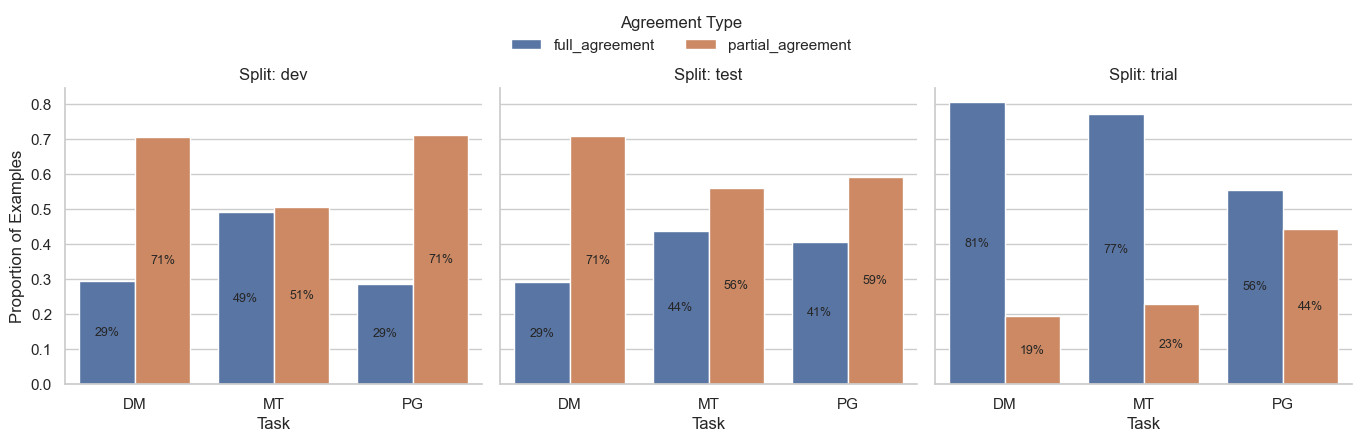

'\nNotes:\n- large share of SHROOM examples involve annotator disagreement, implying that hallucination detection often involves inherently ambiguous cases rather than clear-cut errors\n- the trial split appears comparatively easier, with substantially higher annotator consensus\n'

In [6]:
# analyze agreement among annotators
uncertainty_df = combined_df.copy()
uncertainty_df['agreement_strength'] = np.where(
    uncertainty_df['p(Hallucination)'].isin([0.0, 1.0]),
    'full_agreement',
    'partial_agreement'
)

p_distribution = (
    uncertainty_df
    .groupby(['split', 'task', 'p(Hallucination)'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['split', 'task', 'p(Hallucination)'])
)

agreement_summary = (
    uncertainty_df
    .groupby(['split', 'task', 'agreement_strength'])
    .size()
    .unstack(fill_value=0)
)

display(p_distribution)
display(agreement_summary)

# visual
import seaborn as sns

agreement_summary = (
    uncertainty_df
    .groupby(['split', 'task', 'agreement_strength'])
    .size()
    .reset_index(name='count')
)

agreement_summary['proportion'] = (
    agreement_summary
    .groupby(['split','task'])['count']
    .transform(lambda x: x / x.sum())
)

sns.set(style="whitegrid")

g = sns.catplot(
    data=agreement_summary,
    x="task",
    y="proportion",
    hue="agreement_strength",
    col="split",
    kind="bar",
    palette=["#4C72B0", "#DD8452"],
    errorbar=None,
    height=4,
    aspect=1
)

g.set_axis_labels("Task", "Proportion of Examples")
g.set_titles("Split: {col_name}")
g._legend.remove()

g.fig.legend(
    title="Agreement Type",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

g.fig.subplots_adjust(top=0.80)

for ax in g.axes.flat:
    for container in ax.containers:
        labels = [f"{v*100:.0f}%" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

plt.tight_layout()
plt.show()

'''
Notes:
- large share of SHROOM examples involve annotator disagreement, implying that hallucination detection often involves inherently ambiguous cases rather than clear-cut errors
- the trial split appears comparatively easier, with substantially higher annotator consensus
'''

## Analysis 4: Text Length Features

This section measures the number of whitespace-separated tokens (words) in `src`, `tgt`, and `hyp`.

In [7]:
# analyze word count of src, hyp, and tgt
length_df = combined_df.copy()

for col in ['src', 'tgt', 'hyp']:
    length_df[f'{col}_len'] = length_df[col].fillna('').str.split().str.len()

length_df['hyp_to_tgt_ratio'] = np.where(
    length_df['tgt_len'] > 0,
    length_df['hyp_len'] / length_df['tgt_len'],
    np.nan
)

length_summary = (
    length_df
    .groupby(['split', 'task'])[['src_len', 'tgt_len', 'hyp_len', 'hyp_to_tgt_ratio']]
    .agg(['mean', 'median', 'min', 'max'])
    .round(2)
)

display(length_df.head())
display(length_summary)

'''
Notes:
- DM: long context → short output
- MT: balanced sentence lengths
- PG: very short inputs and outputs
- Model outputs tend to be longer than targets in PG (possible overgeneration)
- DM exhibits extreme output length variability (possible link to hallucination cases)
'''

,hyp,ref,src,tgt,model,task,labels,label,p(Hallucination),split,id,src_len,tgt_len,hyp_len,hyp_to_tgt_ratio
0,"A district of Kowloon, China.",tgt,The City <define> Chiuchow </define> is Kowloo...,The Chaoshan region where the Teochew dialect ...,,DM,"[Hallucination, Hallucination, Hallucination]",Hallucination,1.000000,trial,NaN,42,9,5,0.555556
1,(Wicca) A witchdoctor.,tgt,"“ I went to see the witchdoctor , the <define>...",(South Africa) A traditional tribal diviner or...,,DM,"[Hallucination, Hallucination, Not Hallucination]",Hallucination,0.666667,trial,NaN,27,9,3,0.333333
2,(nautical) A halyard.,tgt,"Haul away , keeping strain on both parts of th...",(nautical) A staff that carries a flag or penn...,,DM,"[Hallucination, Not Hallucination, Not Halluci...",Not Hallucination,0.333333,trial,NaN,30,15,3,0.200000
3,The quality of being rational.,tgt,And what difference is there between the credi...,(archaic) The quality or state of being rational.,,DM,"[Not Hallucination, Not Hallucination, Not Hal...",Not Hallucination,0.000000,trial,NaN,26,8,5,0.625000
4,(uncountable) The study of trees.,tgt,It is now generally supposed that the forbidde...,The worship of trees.,,DM,"[Hallucination, Hallucination, Hallucination]",Hallucination,1.000000,trial,NaN,31,4,5,1.250000


src_len                 tgt_len                hyp_len             \
              mean median min  max    mean median min max    mean median min   
split task                                                                     
dev   DM     31.41   29.0   4  134    8.79    7.0   1  62    5.80    5.0   1   
      MT      5.84    5.0   2   39    7.02    6.0   1  44    6.75    6.0   2   
      PG      4.90    5.0   3    9    5.07    5.0   3  10    7.19    6.0   2   
test  DM     34.37   32.0   4  125    9.26    8.0   1  63    6.48    6.0   1   
      MT      5.77    5.0   1   31    6.91    6.0   1  36    6.66    6.0   2   
      PG      4.74    5.0   2   10    4.73    5.0   2  11    5.31    5.0   1   
trial DM     31.47   31.5   4   63   10.11    8.0   2  28    5.72    5.5   3   
      MT      7.40    6.0   3   37    6.83    6.0   2  28    6.51    6.0   2   
      PG      4.00    4.0   2    5    4.44    4.0   3   8    5.33    6.0   3   

               hyp_to_tgt_ratio                      
           max             mean median   min    max  
split task                                           
dev   DM    15             1.04   0.75  0.06   5.00  
      MT    41             1.00   1.00  0.50   2.00  
      PG    18             1.43   1.40  0.50   2.75  
test  DM    27             0.96   0.75  0.11  14.00  
      MT    39             0.99   1.00  0.40   2.20  
      PG    12             1.15   1.17  0.33   2.25  
trial DM    13             0.85   0.64  0.18   4.00  
      MT    30             0.98   1.00  0.50   1.33  
      PG     7             1.36   1.33  0.62   2.33

'\nNotes:\n- DM: long context → short output\n- MT: balanced sentence lengths\n- PG: very short inputs and outputs\n- Model outputs tend to be longer than targets in PG (possible overgeneration)\n- DM exhibits extreme output length variability (possible link to hallucination cases)\n'

## Analysis 5: Overlap Features

This sections computes lexical overlap and cosine similarity scores between `hyp` and `tgt` / `src`.

In [8]:
# measure lexical overlap (how much of the hypothesis (hyp) reuses words from the source (src) or the target (tgt))
overlap_df = combined_df.copy()

def token_set(text):
    return set(str(text).lower().split())

def overlap_ratio(text_a, text_b):
    tokens_a = token_set(text_a)
    tokens_b = token_set(text_b)
    if len(tokens_a) == 0:
        return np.nan
    return len(tokens_a & tokens_b) / len(tokens_a)

overlap_df['hyp_src_overlap'] = overlap_df.apply(lambda row: overlap_ratio(row['hyp'], row['src']), axis=1)
overlap_df['hyp_tgt_overlap'] = overlap_df.apply(lambda row: overlap_ratio(row['hyp'], row['tgt']), axis=1)

overlap_summary = (
    overlap_df
    .groupby(['split', 'task', 'label'])[['hyp_src_overlap', 'hyp_tgt_overlap']]
    .mean()
    .round(3)
)

display(overlap_summary)

# measure overlap w/ cosine similarity
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")

def cosine_sim(a, b):
    emb = model.encode([str(a), str(b)])
    return cosine_similarity([emb[0]], [emb[1]])[0][0]

overlap_df["hyp_tgt_cosine"] = overlap_df.apply(
    lambda r: cosine_sim(r["hyp"], r["tgt"]), axis=1
)

overlap_df["hyp_src_cosine"] = overlap_df.apply(
    lambda r: cosine_sim(r["hyp"], r["src"]), axis=1
)

cosine_summary = (
    overlap_df
    .groupby(["split","task","label"])[["hyp_tgt_cosine","hyp_src_cosine"]]
    .mean()
)

display(cosine_summary)

'''
Notes:
- non-hallucinated outputs generally exhibit higher lexical overlap with the target than hallucinated outputs
- source overlap is more task-dependent, particularly for MT where source and hypothesis may be in different languages; note, only relevant for PG/MT tasks (ref for DM is always tgt)
- hallucinations are associated with semantic divergence from the expected target, as reflected by consistently lower hypothesis-target cosine similarity
- simiarly w/ lexical overlap, hypothesis-src cosine similarity is task-dependent (PG tasks)
'''

hyp_src_overlap  hyp_tgt_overlap
split task label                                              
dev   DM   Hallucination                0.199            0.172
           Not Hallucination            0.164            0.371
      MT   Hallucination                0.000            0.403
           Not Hallucination            0.003            0.534
      PG   Hallucination                0.386            0.179
           Not Hallucination            0.474            0.289
test  DM   Hallucination                0.190            0.237
           Not Hallucination            0.202            0.384
      MT   Hallucination                0.004            0.441
           Not Hallucination            0.003            0.532
      PG   Hallucination                0.473            0.208
           Not Hallucination            0.576            0.254
trial DM   Hallucination                0.197            0.237
           Not Hallucination            0.143            0.484
      MT   Hallucination                0.020            0.390
           Not Hallucination            0.062            0.709
      PG   Hallucination                0.421            0.033
           Not Hallucination            0.525            0.317

c:\Github Projects\Thesis\Repo\SHROOM-SemEval-2024-Task-6-Model-Size-in-Detection-of-LLM-Hallucinations\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2987.60it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


hyp_tgt_cosine  hyp_src_cosine
split task label                                            
dev   DM   Hallucination            0.419542        0.359522
           Not Hallucination        0.655076        0.382997
      MT   Hallucination            0.551225        0.019866
           Not Hallucination        0.833632        0.021585
      PG   Hallucination            0.521375        0.676794
           Not Hallucination        0.602411        0.740018
test  DM   Hallucination            0.446835        0.343587
           Not Hallucination        0.673155        0.392717
      MT   Hallucination            0.626376        0.029417
           Not Hallucination        0.792125        0.026667
      PG   Hallucination            0.454304        0.657283
           Not Hallucination        0.551847        0.777323
trial DM   Hallucination            0.401436        0.405699
           Not Hallucination        0.705660        0.362570
      MT   Hallucination            0.541251        0.114476
           Not Hallucination        0.871450        0.163759
      PG   Hallucination            0.314335        0.737431
           Not Hallucination        0.663209        0.767226

'\nNotes:\n- non-hallucinated outputs generally exhibit higher lexical overlap with the target than hallucinated outputs\n- source overlap is more task-dependent, particularly for MT where source and hypothesis may be in different languages; note, only relevant for PG/MT tasks (ref for DM is always tgt)\n- hallucinations are associated with semantic divergence from the expected target, as reflected by consistently lower hypothesis-target cosine similarity\n- simiarly w/ lexical overlap, hypothesis-src cosine similarity is task-dependent (PG tasks)\n'

## Analysis 6: Qualitative Sample Review

The section prints a few examples from different certainty bands.

In [9]:
# inspect select examples across bands of hallucination confidence
sample_columns = ['split', 'task', 'label', 'p(Hallucination)', 'src', 'tgt', 'hyp', 'ref']

certain_hallucinations = combined_df[combined_df['p(Hallucination)'] == 1.0][sample_columns]
certain_non_hallucinations = combined_df[combined_df['p(Hallucination)'] == 0.0][sample_columns]
borderline_cases = combined_df[combined_df['p(Hallucination)'].isin([0.4, 0.6])][sample_columns]

print('Certain hallucinations - DM')
display(certain_hallucinations[certain_hallucinations['task'] == 'DM'].head(2))

print('Certain hallucinations - MT')
display(certain_hallucinations[certain_hallucinations['task'] == 'MT'].head(2))

print('Certain hallucinations - PG')
display(certain_hallucinations[certain_hallucinations['task'] == 'PG'].head(2))

print('Certain non-hallucinations - DM')
display(certain_non_hallucinations[certain_non_hallucinations['task'] == 'DM'].head(2))

print('Certain non-hallucinations - MT')
display(certain_non_hallucinations[certain_non_hallucinations['task'] == 'MT'].head(2))

print('Certain non-hallucinations - PG')
display(certain_non_hallucinations[certain_non_hallucinations['task'] == 'PG'].head(2))

print('Borderline cases - DM')
display(borderline_cases[borderline_cases['task'] == 'DM'].head(2))

print('Borderline cases - MT')
display(borderline_cases[borderline_cases['task'] == 'MT'].head(2))

print('Borderline cases - PG')
display(borderline_cases[borderline_cases['task'] == 'PG'].head(2))

Certain hallucinations - DM


,split,task,label,p(Hallucination),src,tgt,hyp,ref
0,trial,DM,Hallucination,1.0,The City <define> Chiuchow </define> is Kowloo...,The Chaoshan region where the Teochew dialect ...,"A district of Kowloon, China.",tgt
4,trial,DM,Hallucination,1.0,It is now generally supposed that the forbidde...,The worship of trees.,(uncountable) The study of trees.,tgt


Certain hallucinations - MT


,split,task,label,p(Hallucination),src,tgt,hyp,ref
48,trial,MT,Hallucination,1.0,Ann a plusieurs amis.,Ann has many friends.,He's got several friends.,either
52,trial,MT,Hallucination,1.0,"Comment épelles-tu ""pretty"" ?","How do you spell ""pretty""?","How'd you get ""pretty""?",either


Certain hallucinations - PG


...

,split,task,label,p(Hallucination),src,tgt,hyp,ref
86,dev,DM,Not Hallucination,0.4,The <define> sacrifice bunt </define> was fiel...,(baseball) A ball that has been intentionally ...,(baseball) A sacrifice bunt.,tgt
88,dev,DM,Not Hallucination,0.4,The <define> metaontology </define> debate has...,The ontology of ontology.,(linguistics) The study of the relationships b...,tgt


Borderline cases - MT


,split,task,label,p(Hallucination),src,tgt,hyp,ref
393,dev,MT,Not Hallucination,0.4,"Как у Тома с французским? - ""Неплохо"".","How's Tom's French? ""Pretty good.""","How about Tom and French? - ""Not bad.""",either
411,dev,MT,Not Hallucination,0.4,Срок действия водительских прав Тома истек.,Tom's driver's license has expired.,The duration of Tom’s driving rights expired.,either


Borderline cases - PG


,split,task,label,p(Hallucination),src,tgt,hyp,ref
274,dev,PG,Not Hallucination,0.4,Are we resolved?,Do we have a deal?,"So, what, we're in the clear now?",either
281,dev,PG,Not Hallucination,0.4,I'll take good care of you.,I'm gonna look after you.,I'm going to take a good care of you now.,either


## Analysis 7: Data Overlap Review

The section investigates data overlap between data splits.

In [40]:
# check for possible overlap between the trial, dev, and test splits
trial_dev = pd.merge(trial_df, dev_df, on=['src', 'tgt', 'hyp','task'])
print(f"Data overlap between trial and dev: {len(trial_dev)} examples")

trial_test = pd.merge(trial_df, test_df, on=['src', 'tgt', 'hyp','task'])
print(f"Data overlap between trial and test: {len(trial_test)} examples")

dev_test = pd.merge(dev_df, test_df, on=['src', 'tgt', 'hyp','task'])
print(f"Data overlap between dev and test: {len(dev_test)} examples")

'''
Notes:
- will need to be cognizant of exact duplicates across sets if utilized for model training/fine-tuning, etc.
'''

Data overlap between trial and dev: 12 examples
Data overlap between trial and test: 0 examples
Data overlap between dev and test: 4 examples


'\nNotes:\n- will need to be cognizant of exact duplicates across sets if utilized for model training/fine-tuning, etc.\n'